# Calibration Analysis — ECE & Temperature Scaling

Benchmark dataset (N=2495, pos=1116, 44.7%).  
- **Our models** (MTL/STL/ABC/JointSTL): raw ECE + temperature-scaled ECE  
- **Probability-output SOTA** (BigMHC, MUNIS): raw ECE — included because they output calibrated probability scores  
- Rank-based tools (netMHCpan, MHCflurry, PRIME 2.0) are excluded — their scores have no probability interpretation, making ECE meaningless for them  
- Temperature *T* fit on the held-out val set during training (honest; not optimised on the test set)  
- Rank-based metrics (AUROC, AP, PPV@10%) are unaffected by temperature scaling

In [47]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize_scalar
from scipy.special import expit, logit
from sklearn.metrics import roc_auc_score, average_precision_score
warnings.filterwarnings('ignore')

os.chdir(os.path.dirname(os.path.abspath('__file__')))

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
os.makedirs('figures', exist_ok=True)

In [48]:
# ── Metric helpers ─────────────────────────────────────────────────────────────

def ece(yt, yp, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    val = 0.0
    for i in range(n_bins):
        m = (yp >= bins[i]) & (yp < bins[i + 1])
        if m.sum() == 0:
            continue
        val += m.sum() * abs(yt[m].mean() - yp[m].mean())
    return val / len(yt)


def fit_temperature(yt, yp):
    """Fit scalar T minimising NLL: logits -> logits/T -> sigmoid."""
    eps = 1e-6
    yp_c = np.clip(yp, eps, 1 - eps)
    logits = logit(yp_c)
    def nll(T):
        p = expit(logits / T)
        p = np.clip(p, eps, 1 - eps)
        return -np.mean(yt * np.log(p) + (1 - yt) * np.log(1 - p))
    result = minimize_scalar(nll, bounds=(0.01, 20.0), method='bounded')
    return result.x


def apply_temperature(yp, T):
    eps = 1e-6
    return expit(logit(np.clip(yp, eps, 1 - eps)) / T)


def reliability_curve(yt, yp, n_bins=10):
    """Return (mean_pred, frac_pos, bin_counts) for plotting."""
    bins = np.linspace(0, 1, n_bins + 1)
    mean_pred, frac_pos, counts = [], [], []
    for i in range(n_bins):
        m = (yp >= bins[i]) & (yp < bins[i + 1])
        if m.sum() == 0:
            continue
        mean_pred.append(yp[m].mean())
        frac_pos.append(yt[m].mean())
        counts.append(m.sum())
    return np.array(mean_pred), np.array(frac_pos), np.array(counts)

In [49]:
# ── Load predictions ───────────────────────────────────────────────────────────

def load(path, score_col, label_source=None):
    if not os.path.exists(path):
        return None, None
    df = pd.read_csv(path)
    if score_col not in df.columns:
        return None, None
    if label_source is not None:
        ref = pd.read_csv(label_source)[['Peptide', 'MHC', 'Label']]
        pep_col = 'pep' if 'pep' in df.columns else 'Peptide'
        mhc_col = 'mhc' if 'mhc' in df.columns else 'MHC'
        df = df.rename(columns={pep_col: 'Peptide', mhc_col: 'MHC'})
        df = df.merge(ref, on=['Peptide', 'MHC'], how='left')
    yt = df['Label'].values.astype(float)
    yp = df[score_col].values.astype(float)
    mask = ~np.isnan(yp) & ~np.isnan(yt)
    return yt[mask], yp[mask]


ROOT = '..'
PR   = f'{ROOT}/pred_results'

# Our models
OUR_MODELS = {
    'MTL':      (f'{PR}/MTL/benchmark_predictions.csv',          'score'),
    'STL':      (f'{PR}/STL/benchmark_predictions.csv',          'score'),
    'ABC':      (f'{PR}/ABC/benchmark_predictions.csv',          'score'),
    'JointSTL': (f'{PR}/JointSTL/benchmark_predictions.csv',     'score'),
}

# Probability-output SOTA only (rank-based tools excluded — ECE not meaningful for them)
SOTA_MODELS = {
    'BigMHC': (f'{PR}/bigmhc/BenchmarkSet_bigmhc.csv', 'BigMHC_IM', f'{PR}/MTL/benchmark_predictions.csv'),
    'MUNIS':  (f'{PR}/munis/BenchmarkSet_munis_predictions.csv', 'score'),
}

# Load our models
our_data = {}
for name, (path, col) in OUR_MODELS.items():
    yt, yp = load(path, col)
    if yt is not None:
        our_data[name] = (yt, yp)
        print(f'{name:12s}  N={len(yt)}  pos={int(yt.sum())}')
    else:
        print(f'{name:12s}  [NOT FOUND]')

# Shuffle excluded from ECE (mean of 10 seeds — temperature scaling not meaningful for an ensemble)

# Load SOTA
sota_data = {}
for name, entry in SOTA_MODELS.items():
    path, col = entry[0], entry[1]
    label_src = entry[2] if len(entry) > 2 else None
    yt, yp = load(path, col, label_source=label_src)
    if yt is not None:
        sota_data[name] = (yt, yp)
        print(f'{name:12s}  N={len(yt)}  pos={int(yt.sum())}')
    else:
        print(f'{name:12s}  [NOT FOUND]')

MTL           N=2495  pos=1116
STL           N=2495  pos=1116
ABC           N=2495  pos=1116
JointSTL      N=2495  pos=1116
BigMHC        N=2495  pos=1116
MUNIS         N=2495  pos=1116


In [50]:
# ── Compute ECE and apply val-fitted temperature for our models ────────────────

# T values fit on the held-out val set during training (not on the test benchmark)
VAL_T = {'MTL': 3.9836, 'STL': 9.4500, 'ABC': 18.0839, 'JointSTL': 3.4474}

results = {}
print(f"{'Model':<14}  {'T':>6}  {'ECE_raw':>8}  {'ECE_scaled':>10}")
print('-' * 46)

for name, (yt, yp) in our_data.items():
    T        = VAL_T[name]
    yp_sc    = apply_temperature(yp, T)
    ece_raw  = ece(yt, yp)
    ece_sc   = ece(yt, yp_sc)
    results[name] = dict(yt=yt, yp=yp, yp_scaled=yp_sc, T=T,
                         ece_raw=ece_raw, ece_scaled=ece_sc, is_sota=False)
    print(f'{name:<14}  {T:6.4f}  {ece_raw:8.4f}  {ece_sc:10.4f}')

print()
print(f"{'SOTA':<14}  {'ECE_raw':>8}")
print('-' * 25)
for name, (yt, yp) in sota_data.items():
    ece_raw = ece(yt, yp)
    results[name] = dict(yt=yt, yp=yp, yp_scaled=None, T=None,
                         ece_raw=ece_raw, ece_scaled=None, is_sota=True)
    print(f'{name:<14}  {ece_raw:8.4f}')

Model                T   ECE_raw  ECE_scaled
----------------------------------------------
MTL             3.9836    0.3871      0.2057
STL             9.4500    0.4100      0.1947
ABC             18.0839    0.3601      0.1268
JointSTL        3.4474    0.4091      0.2029

SOTA             ECE_raw
-------------------------
BigMHC            0.2050
MUNIS             0.4167


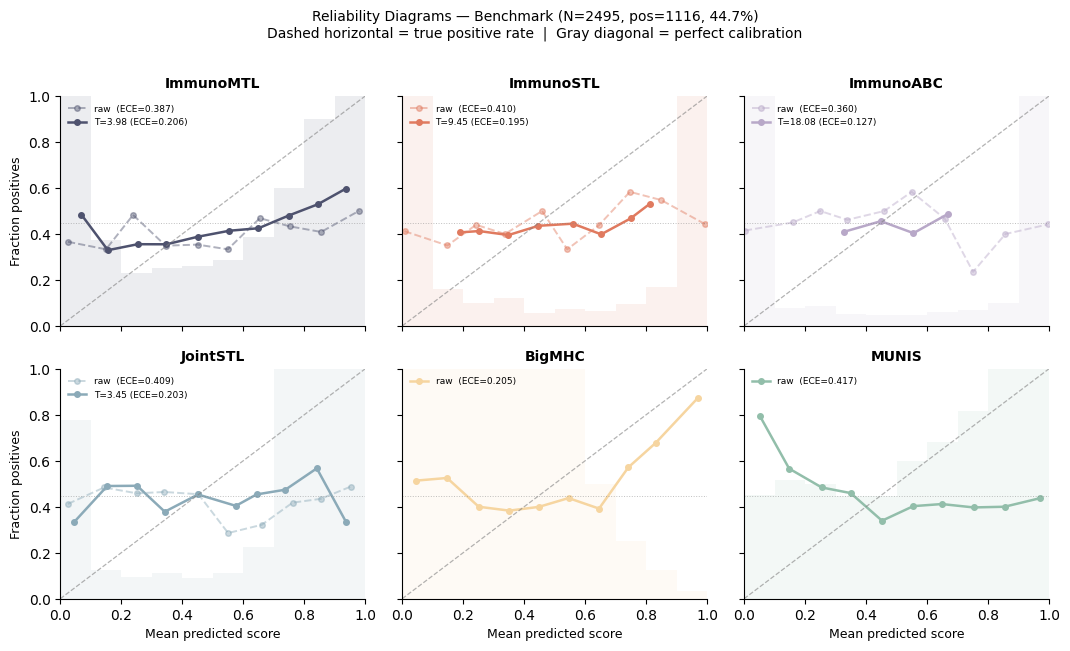

Saved sup_figures/calibration_reliability.{pdf,png}


In [51]:
# ── Figure 1: Reliability diagrams ────────────────────────────────────────────

COLOR = {
    'MTL':       '#4E526E',
    'STL':       '#E07A5F',
    'ABC':       '#B8A8C8',
    'JointSTL':  '#8BAAB8',
    'BigMHC':    '#F6D5A0',
    'MUNIS':     '#92BEAA',
}
DISPLAY = {
    'MTL':       'ImmunoMTL',
    'STL':       'ImmunoSTL',
    'ABC':       'ImmunoABC',
    'JointSTL':  'JointSTL',
    'BigMHC':    'BigMHC',
    'MUNIS':     'MUNIS',
}

MODEL_ORDER = ['MTL', 'STL', 'ABC', 'JointSTL', 'BigMHC', 'MUNIS']
all_names = [m for m in MODEL_ORDER if m in results]
n = len(all_names)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.6, nrows * 3.2),
                          sharex=True, sharey=True)
axes = axes.flatten()

N_BINS = 10

for ax_i, name in enumerate(all_names):
    ax  = axes[ax_i]
    r   = results[name]
    yt, yp = r['yt'], r['yp']
    col = COLOR.get(name, '#888')

    ax.hist(yp, bins=N_BINS, range=(0,1), density=True,
            alpha=0.10, color=col, zorder=0)

    mp, fp, cnt = reliability_curve(yt, yp, N_BINS)
    if r['is_sota']:
        ax.plot(mp, fp, 'o-', color=col, lw=1.8, ms=4, label=f'raw  (ECE={r["ece_raw"]:.3f})')
    else:
        ax.plot(mp, fp, 'o--', color=col, lw=1.4, ms=4, alpha=0.45, label=f'raw  (ECE={r["ece_raw"]:.3f})')
        mp_s, fp_s, _ = reliability_curve(yt, r['yp_scaled'], N_BINS)
        ax.plot(mp_s, fp_s, 'o-', color=col, lw=1.8, ms=4, label=f'T={r["T"]:.2f} (ECE={r["ece_scaled"]:.3f})')

    ax.plot([0,1],[0,1],'--',color='gray',lw=0.9,alpha=0.6)
    ax.axhline(0.447, color='gray', lw=0.7, ls=':', alpha=0.5)

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(DISPLAY[name], fontsize=10, fontweight='bold')
    ax.legend(fontsize=6.5, loc='upper left', frameon=False)
    ax.spines[['top','right']].set_visible(False)
    if ax_i % ncols == 0:
        ax.set_ylabel('Fraction positives', fontsize=9)
    if ax_i // ncols == nrows - 1:
        ax.set_xlabel('Mean predicted score', fontsize=9)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Reliability Diagrams — Benchmark (N=2495, pos=1116, 44.7%)\n'
             'Dashed horizontal = true positive rate  |  Gray diagonal = perfect calibration',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('sup_figures/calibration_reliability.pdf', bbox_inches='tight')
plt.savefig('sup_figures/calibration_reliability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved sup_figures/calibration_reliability.{pdf,png}')

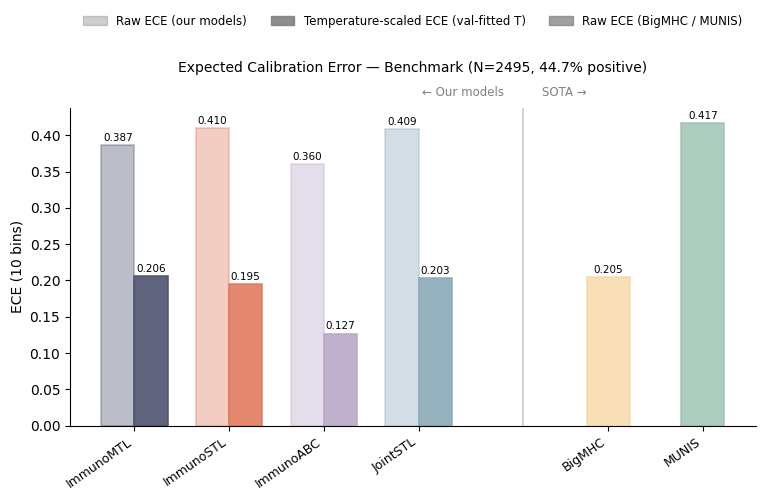

Saved sup_figures/calibration_ece_bar.{pdf,png}


In [53]:
# ── Figure 2: ECE summary bar chart ───────────────────────────────────────────

our_names  = [n for n in all_names if not results[n]['is_sota']]
sota_names = [n for n in all_names if results[n]['is_sota']]

fig, ax = plt.subplots(figsize=(8, 5.3))

bar_w = 0.35
x_our  = np.arange(len(our_names))
x_sota = np.arange(len(sota_names)) + len(our_names) + 1.0

# Our models: paired bars (raw + scaled)
for i, name in enumerate(our_names):
    r   = results[name]
    col = COLOR[name]
    ax.bar(x_our[i] - bar_w/2, r['ece_raw'],   bar_w, color=col, alpha=0.38, edgecolor=col, lw=1.2)
    ax.bar(x_our[i] + bar_w/2, r['ece_scaled'], bar_w, color=col, alpha=0.90, edgecolor=col, lw=1.2)
    ax.text(x_our[i] - bar_w/2, r['ece_raw']    + 0.003, f"{r['ece_raw']:.3f}",    ha='center', va='bottom', fontsize=7.5)
    ax.text(x_our[i] + bar_w/2, r['ece_scaled'] + 0.003, f"{r['ece_scaled']:.3f}", ha='center', va='bottom', fontsize=7.5)

# Prob-output SOTA: single bar
for i, name in enumerate(sota_names):
    r   = results[name]
    col = COLOR[name]
    ax.bar(x_sota[i], r['ece_raw'], bar_w * 1.3, color=col, alpha=0.75, edgecolor=col, lw=1.2)
    ax.text(x_sota[i], r['ece_raw'] + 0.003, f"{r['ece_raw']:.3f}", ha='center', va='bottom', fontsize=7.5)

# separator between our / SOTA
sep_x = len(our_names) - 0.4 + 0.5
ax.axvline(sep_x, color='#ccc', lw=1.2, ls='-')

from matplotlib.transforms import blended_transform_factory
trans = blended_transform_factory(ax.transData, ax.transAxes)
ax.text(sep_x + 0.20, 1.07, 'SOTA →',  fontsize=8.5, color='gray', ha='left',  va='top', transform=trans)
ax.text(sep_x - 0.20, 1.07, '← Our models',  fontsize=8.5, color='gray', ha='right', va='top', transform=trans)

all_x = np.concatenate([x_our, x_sota])
ax.set_xticks(all_x)
ax.set_xticklabels([DISPLAY[n] for n in our_names + sota_names], fontsize=9, ha="right", rotation=35)

raw_patch    = mpatches.Patch(color='gray', alpha=0.38, label='Raw ECE (our models)')
scaled_patch = mpatches.Patch(color='gray', alpha=0.90, label='Temperature-scaled ECE (val-fitted T)')
sota_patch   = mpatches.Patch(color='gray', alpha=0.75, label='Raw ECE (BigMHC / MUNIS)')
ax.legend(handles=[raw_patch, scaled_patch, sota_patch],
          fontsize=8.5, frameon=False, ncol=3,
          bbox_to_anchor=(0.5, 1.22), loc='lower center')

ax.set_ylabel('ECE (10 bins)', fontsize=10)
ax.set_title('Expected Calibration Error — Benchmark (N=2495, 44.7% positive)',
             fontsize=10, pad=26)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('sup_figures/calibration_ece_bar.pdf', bbox_inches='tight')
plt.savefig('sup_figures/calibration_ece_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved sup_figures/calibration_ece_bar.{pdf,png}')